In [ ]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
import cmcrameri as cm
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import statsmodels.api as sm
import pymannkendall as mk
from global_land_mask import globe

In [ ]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
start_year = 2003
end_year = 2025
ref_timeslice=slice(1970,2000)

Arctic_limit = 60
land_longitudes = slice(0,300) # Exclude Greenland

spring_summer_months = [3, 4, 5, 6, 7, 8]
spring_summer_label = 'MAMJJA'
summer_months = [6, 7, 8]

## Extract data and calculate regional averages

### Snow cover data

Url: https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00756

Robinson, David A.; Estilow, Thomas W.; and NOAA CDR Program (2012): NOAA Climate Data Record (CDR) of Northern Hemisphere (NH) Snow Cover Extent (SCE), Version 1. NOAA National Centers for Environmental Information. doi:10.7289/V5N014G9 [20.02.2026].

In [11]:
filepath = rpath+'nhsce_v01r01_19661004_20260202.nc'
sce = xr.open_dataset(filepath)

# Select times with meaningful data
sce = sce.sel(time=slice('1975-01-01','2026-01-01'))

# Select area
land_weights = sce.land # Extract land weights
latitude_weights = sce.latitude >= Arctic_limit # Select latitudes
longitude_weights = 1-(sce.longitude >= -60)*(sce.longitude <=0) # Select longitudes, i.e. longitudes between 0 and 300 degrees east
total_weights = land_weights*longitude_weights*latitude_weights # Create weights that include all selected land areas

# Calculate area-weighted average snow cover extent across area
area_weights = sce.area
total_weights_area = (area_weights*total_weights)
total_area = total_weights_area.sum() # Find total area sum for seleced grid boxes
snow_cover_extent = (sce['snow_cover_extent']*total_weights_area/total_area).sum(('y','x'))

#Convert from fraction to percentage
snow_cover_extent = snow_cover_extent*100

### Soil moisture data

In [8]:
SM_ERA5 = xr.open_dataset(rpath+'SM_ERA5_1970_2025_10cm_20cm.nc')

# Convert units from m3/m3 to kg/m2
SM_ERA5_converted = SM_ERA5['swvl_10cm']*100 # Conversion factor = 1000 kg/m3 * 0.10 m

# Calculate area-weighted regional average
SM_ERA5 = functions.computeWeightedMean(SM_ERA5_converted.sel(lon=land_longitudes))

In [10]:
SM_WM = xr.open_dataset(rpath+'SM_WangMao_1970_2016_masked.nc')

# Calculate area-weighted regional average
SM_WM = functions.computeWeightedMean(SM_WM['mrsos'].sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))

### Cloud cover data

In [12]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202512.nc'
CERES  = xr.open_dataset(filepath)

ds = CERES.copy()
# Convert CERES longitudes to match land mask 
ds.coords['lon']= (ds.coords['lon'] + 180) % 360- 180
ds = ds.sortby(ds.lon)

# Get land mask for CERES grid
lats = ds.lat.expand_dims(dims=len(ds.lon)).T
lons = ds.lon.expand_dims(dims=len(ds.lat))
landmask = globe.is_land(lats, lons)
landmask = xr.DataArray(landmask, dims = ["lat","lon"], coords=dict(lat=ds.lat, lon=ds.lon))

# Regrid land mask to original CERES data
lons = np.array(landmask.lon)
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
landmask.coords['lon']= lons
landmask = landmask.sortby(landmask.lon)

# Calculate area-weighted regional average using land mask
cloud_cover = functions.computeWeightedMeanMasked(   CERES['cldarea_total_daynight_mon'].sel(lat=slice(Arctic_limit, 90),lon=land_longitudes), 
                                                                                landmask.sel(lat=slice(Arctic_limit, 90),lon=land_longitudes))


### Temperature data

In [13]:
temp_ERA5_JJA = xr.open_dataset(rpath+'temperature2m_ERA5_JJA_annual.nc')

deltaT =  temp_ERA5_JJA['t2m'].sel(year=slice(start_year,end_year)) - temp_ERA5_JJA['t2m'].sel(year=ref_timeslice).mean('year')

## Calculate seasonal averages

In [14]:
# Snow cover extent

sce_season = snow_cover_extent.sel(time = snow_cover_extent['time.month'].isin(spring_summer_months)) # Select April, May, June, July and August
sce_season = sce_season.groupby(sce_season['time.year']).mean('time')

# Soil moisture ERA5-Land

SM_ERA5_season = SM_ERA5.sel(time = SM_ERA5['time.month'].isin(summer_months)) # Select June, July and August
SM_ERA5_season = SM_ERA5_season.groupby(SM_ERA5_season['time.year']).mean('time')
# Calculate anomaly from reference period
SM_ERA5_season = SM_ERA5_season - SM_ERA5_season.sel(year=ref_timeslice).mean('year')

# Soil moisture Wang & Mao (2021)

SM_WM_season = SM_WM.sel(time = SM_WM['time.month'].isin(summer_months)) # Select June, July and August
SM_WM_season = SM_WM_season.groupby(SM_WM_season['time.year']).mean('time')
# Calculate anomaly from reference period
SM_WM_season = SM_WM_season - SM_WM_season.sel(year=ref_timeslice).mean('year')

# Cloud cover

cc_season = cloud_cover.sel(time = cloud_cover['time.month'].isin(summer_months)) # Select June, July and August
cc_season = cc_season.groupby(cc_season['time.year']).mean('time')


## Calculate trends and significance test

In [15]:
sce_slope, sce_intercept, _, _, sce_p = functions.theilslopes_mk_prewhitened_test(sce_season.sel(year=slice(start_year, end_year)))

SM_ERA5_slope, SM_ERA5_intercept, _, _, SM_ERA5_p = functions.theilslopes_mk_prewhitened_test(SM_ERA5_season.sel(year=slice(start_year, end_year)))

SM_WM_slope, SM_WM_intercept, _, _, SM_WM_p = functions.theilslopes_mk_prewhitened_test(SM_WM_season.sel(year=slice(start_year, 2016)))

cc_slope, cc_intercept, _, _, cc_p = functions.theilslopes_mk_prewhitened_test(cc_season.sel(year=slice(start_year, end_year)))

## Plotting

In [ ]:
def xr_add_cyclic_point(da):
    """
    Inputs
    da: xr.DataArray with dimensions (time,lat,lon)
    """
    from cartopy.util import add_cyclic_point
    import xarray as xr 

    # Use add_cyclic_point to interpolate input data
    lon_idx = da.dims.index('lon')
    wrap_data, wrap_lon = add_cyclic_point(da.values, coord=da.lon, axis=lon_idx)

    # Generate output DataArray with new data but same structure as input
    outp_da = xr.DataArray(data=wrap_data, 
                           coords = {'lat': da.lat, 'lon': wrap_lon}, 
                           dims=da.dims, 
                           attrs=da.attrs)
    
    return outp_da

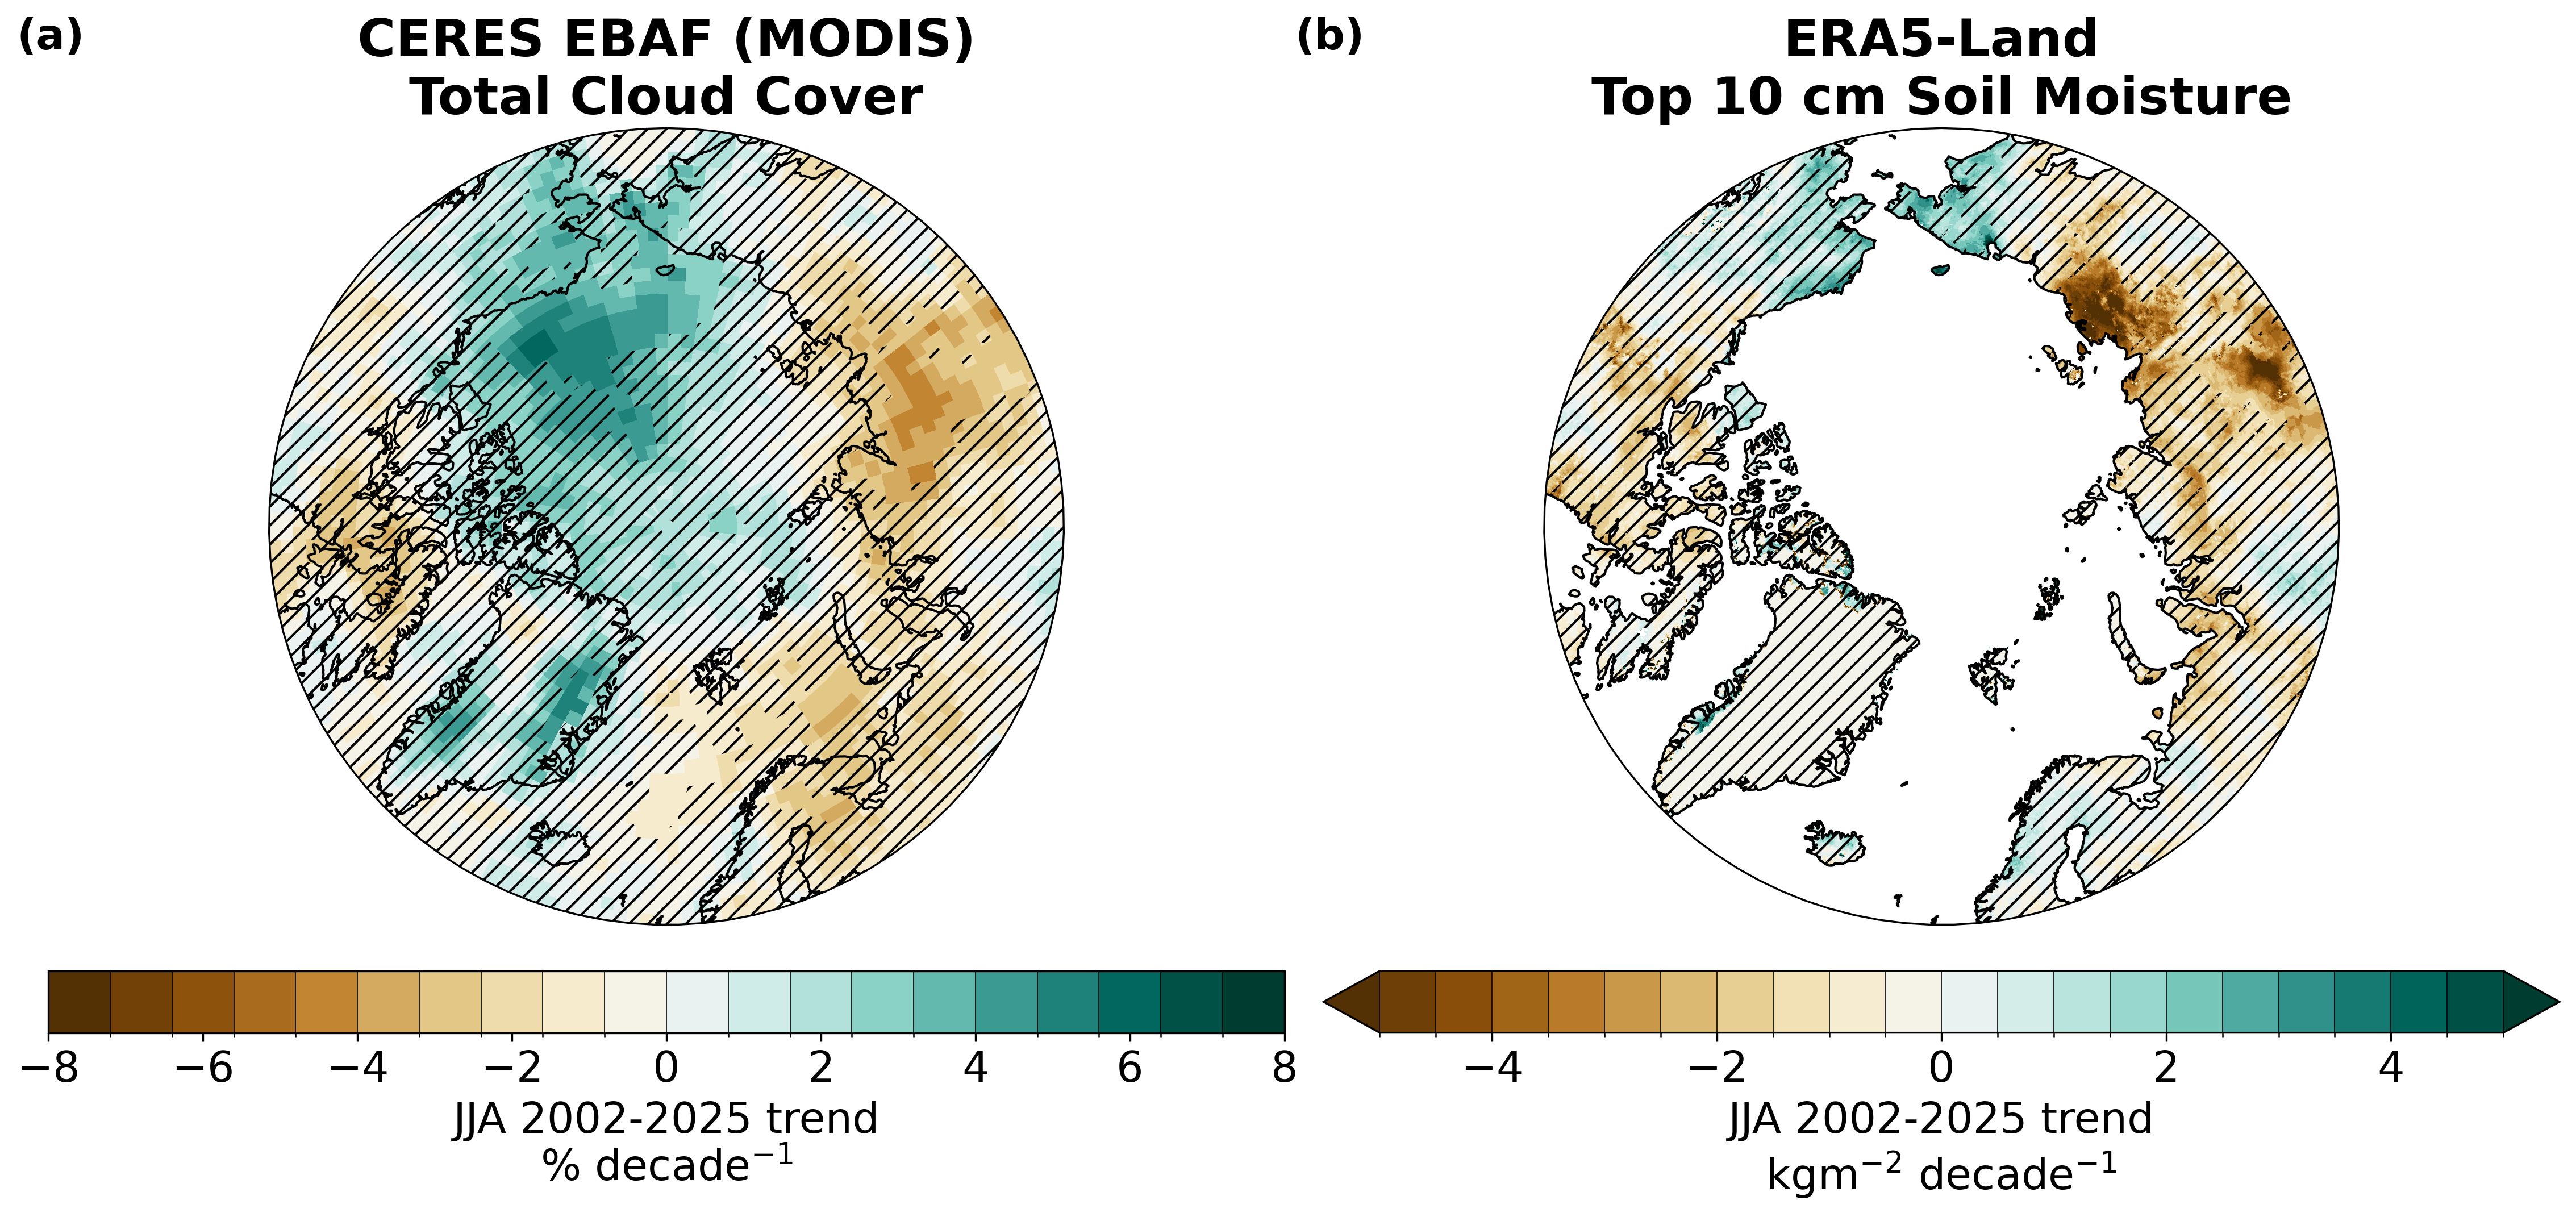

In [ ]:
labels = [['(a)','(a)','(b)','(b)']]

significance_level = 0.05
hatch_density = 5

# Create figure
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(15, 7),dpi=300, 
                              constrained_layout=True)

# Remove axis from map plots
for label in ['(a)', '(b)']:
      ax = axs[label]
      ax.axis('off')
# Add new subplots with Arctic map projection
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(0, 90))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(0, 90))


# Row |: spatial trends
for ax, title, unit, file, limit in zip([ax1, ax2], 
                                  ['CERES EBAF (MODIS)\nTotal Cloud Cover', 'ERA5-Land\nTop 10 cm Soil Moisture'],
                                  ['% decade$^{-1}$', 'kgm$^{-2}$ decade$^{-1}$'],
                                  ['CERES_trends_summer_2003_2025.nc', 'SM_ERA5_trends_JJA_2003_2035.nc'], 
                                  [8, 5]):
    levels = np.linspace(-limit, limit, 21)
    functions.polarCentral_set_latlim([60,90], ax)
    ds = xr.open_dataset(rpath+file)
    if ax == ax1:
        data = ds['trend']*10 # multiply by 10 to get trend per decade
    elif ax == ax2:
        data = ds['trend'].T*10 # multiply by 10 to get trend per decade 
    map = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap='BrBG', levels=levels,
                                        add_colorbar=False)
    #hatch = ax.contourf(ds.lon, ds.lat, ds['p_value'].T < significance_level, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*'.', hatch_density*'.'])
    hatch_density=3
    hatch_style='/'
    insignificant_data = xr_add_cyclic_point(ds['p_value'].T > significance_level)
    hatch = ax.contourf(insignificant_data.lon, insignificant_data.lat, insignificant_data, transform=ccrs.PlateCarree(), colors='none', levels=[.5,1.5], hatches=[hatch_density*hatch_style, hatch_density*hatch_style])    


    #hatch.set_edgecolor('black')
    #hatch._hatch_color = (1, 1, 1, 1.0)
    #hatch._hatch_color = (0.1, 0.1, 0.1, 0.1)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.coastlines()

    cb = plt.colorbar(map, ax=ax, ticks=[-10, -8,-6,-4,-2,0,2,4,6,8,10],drawedges=True,
                        location='bottom',orientation='horizontal')

    cb.set_label(label='JJA 2003-2025 trend\n'+unit,fontsize=18)
    cb.ax.tick_params(labelsize=18)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
#fig.tight_layout()

#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig4.png')
#fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig4.pdf')

In [ ]:
#CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2_Subset_200207-202407.nc')
CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202512.nc')
CERES = CERES.sel(time=slice('2003-01-01','2025-12-1'))

# Select season
timeslice_trend=slice(2003,2025)
CERES_season = CERES_Arctic.sel(time=CERES_Arctic.time.dt.season==season)
# Annual season mean
CERES_season_annual = CERES_season.groupby(CERES_season.time.dt.year).mean('time')
# Create weighted linear regression
x = CERES_season_annual.year.values
x = x
y = CERES_season_annual.values
weights = np.ones(len(x))

# Fit weighted least squares regression model
X = sm.add_constant(x)
model = sm.WLS(y, X, weights=weights)
CERES_fit = model.fit()
CERES_slope = CERES_fit.params[1]
CERES_intercept = CERES_fit.params[0]
CERES_p_value = CERES_fit.pvalues[1]
CERES_std_err = CERES_fit.bse[1]
print(CERES_fit.summary())

for season in ["JJA"]:
    ds_season = CERES['cldarea_total_daynight_mon'].sel(time=CERES.time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')
    
    x = ds_annual.year.values
    weights = np.ones(len(x))
    # Add a smaller weight to first point, as it does not include June
    weights[0] = 2/3
    X = sm.add_constant(x)

    trends = np.ones((len(CERES.lon),len(CERES.lat)))*np.nan
    p_values = np.ones((len(CERES.lon),len(CERES.lat)))*np.nan
    for ilon in range(len(CERES.lon)):
        for ilat in range(len(CERES.lat)):
            y = ds_annual.isel(lon=ilon, lat=ilat).values
            model = sm.WLS(y, X, weights=weights)
            CERES_fit = model.fit()

            trends[ilon, ilat] = CERES_fit.params[1]
            p_values[ilon, ilat] = CERES_fit.pvalues[1]
    
    ds_annual['trend'] = ({'lon':CERES.lon, 'lat':CERES.lat}, trends)
    ds_annual['p_value'] = ({'lon':CERES.lon, 'lat':CERES.lat}, p_values)

    ds_annual.to_netcdf(rpath+"CERES_trends_"+season+"_2002_2025.nc")

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.173
Model:                            WLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     4.617
Date:                Wed, 18 Mar 2026   Prob (F-statistic):             0.0429
Time:                        17:39:46   Log-Likelihood:                -40.430
No. Observations:                  24   AIC:                             84.86
Df Residuals:                      22   BIC:                             87.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        244.0488     80.884      3.017      0.0

In [6]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
CERES = xr.open_dataset(rpath+'CERES_EBAF-TOA_Ed4.2_Subset_200207-202407.nc')

datadir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'
landfrac = xr.open_dataarray(datadir+'LANDFRAC_piClim.nc')
landmask = landfrac.isel(time=0)
oceanmask = 1-landmask

# Interpolate to 
landmask_CERES = landmask.interp_like(CERES.isel(time=0))
landmask_CERES = landmask_CERES.where(landmask_CERES>=0)
landmask_CERES = landmask_CERES.fillna(0)

oceanmask_CERES = 1-landmask_CERES

In [65]:
SM_ERA5

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 168, lat: 301, lon: 3600)
Coordinates:
  * time       (time) datetime64[ns] 1kB 1970-06-01 1970-07-01 ... 2025-08-01
    expver     (time) <U4 3kB ...
  * lat        (lat) float64 2kB 60.0 60.1 60.2 60.3 ... 89.7 89.8 89.9 90.0
  * lon        (lon) float64 29kB 0.1 0.2 0.3 0.4 ... 359.7 359.8 359.9 360.0
    number     int64 8B ...
Data variables:
    swvl1      (time, lat, lon) float32 728MB ...
    swvl2      (time, lat, lon) float32 728MB nan nan nan nan ... nan nan nan
    swvl_20cm  (time, lat, lon) float32 728MB ...
    swvl_10cm  (time, lat, lon) float32 728MB nan nan nan nan ... nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-30T14:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [66]:
SM_ERA5

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 168, lat: 301, lon: 3600)
Coordinates:
  * time       (time) datetime64[ns] 1kB 1970-06-01 1970-07-01 ... 2025-08-01
    expver     (time) <U4 3kB ...
  * lat        (lat) float64 2kB 60.0 60.1 60.2 60.3 ... 89.7 89.8 89.9 90.0
  * lon        (lon) float64 29kB 0.1 0.2 0.3 0.4 ... 359.7 359.8 359.9 360.0
    number     int64 8B ...
Data variables:
    swvl1      (time, lat, lon) float32 728MB ...
    swvl2      (time, lat, lon) float32 728MB nan nan nan nan ... nan nan nan
    swvl_20cm  (time, lat, lon) float32 728MB ...
    swvl_10cm  (time, lat, lon) float32 728MB nan nan nan nan ... nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-30T14:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [72]:
# Select season
timeslice_trend=slice('2002-01-01','2025-12-01')
SM_ERA5_slice = SM_ERA5.sel(time=timeslice_trend)

# Annual season mean
ds_season = SM_ERA5_slice['swvl_10cm'].sel(time=SM_ERA5_slice.time.dt.season=='JJA')
ds_annual = ds_season.groupby(ds_season.time.dt.year).mean('time')

x = ds_annual.year.values
X = sm.add_constant(x)

trends = np.ones((len(SM_ERA5_slice.lon),len(SM_ERA5_slice.lat)))*np.nan
p_values = np.ones((len(SM_ERA5_slice.lon),len(SM_ERA5_slice.lat)))*np.nan
for ilon in range(len(SM_ERA5_slice.lon)):
    for ilat in range(len(SM_ERA5_slice.lat)):
        y = ds_annual.isel(lon=ilon, lat=ilat).values*100
        model = sm.WLS(y, X)
        fit = model.fit()

        trends[ilon, ilat] = fit.params[1]
        p_values[ilon, ilat] = fit.pvalues[1]

ds_annual['trend'] = ({'lon':SM_ERA5_slice.lon, 'lat':SM_ERA5_slice.lat}, trends)
ds_annual['p_value'] = ({'lon':SM_ERA5_slice.lon, 'lat':SM_ERA5_slice.lat}, p_values)

ds_annual.to_netcdf(rpath+"SM_ERA5_trends_"+season+"_2002_2025.nc")

In [ ]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual['swvl_10cm']*100 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year, converted_ds_annual.isel(longitude=ilon, latitude=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_2002_2025.nc")

In [70]:
var = 'swvl1'
ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

In [ ]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year, converted_ds_annual.isel(longitude=ilon, latitude=ilat))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_20cm_trends_"+season+".nc")


In [75]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year.sel(year=slice(2002,2024)), converted_ds_annual.isel(longitude=ilon, latitude=ilat).sel(year=slice(2002,2024)))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_2002_2024.nc")


In [25]:
from scipy import stats
savedir="/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"
var='swvl1'

#for season in ["DJF", "MAM","JJA","SON"]:
for season in ["JJA"]:
    ds_season = SM_ERA5.sel(valid_time=SM_ERA5.valid_time.dt.season==season)
    ds_annual = ds_season.groupby(ds_season.valid_time.dt.year).mean('valid_time')
    converted_ds_annual = ds_annual[var]*70 # from m3/m3 to kg/m2

    trends = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    p_values = np.ones((len(SM_ERA5.longitude),len(SM_ERA5.latitude)))*np.nan
    for ilon in range(len(SM_ERA5.longitude)):
        for ilat in range(len(SM_ERA5.latitude)):
            slope, intercept, r_value, p_value, std_err = stats.linregress(converted_ds_annual.year.sel(year=slice(1970,2016)), converted_ds_annual.isel(longitude=ilon, latitude=ilat).sel(year=slice(1970,2016)))
            trends[ilon, ilat] = slope
            p_values[ilon, ilat] = p_value
    
    ds_annual['trend'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, trends)
    ds_annual['p_value'] = ({'longitude':SM_ERA5.longitude, 'latitude':SM_ERA5.latitude}, p_values)

    ds_annual.to_netcdf(savedir+"SM_ERA5_trends_"+season+"_1970_2016.nc")


In [4]:
season="JJA"
rpath = "/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/"
ds_annual = xr.open_dataset(rpath+"SM_ERA5_trends_"+season+".nc")
ds_annual = ds_annual.reindex(latitude=list(reversed(ds_annual.latitude)))

In [36]:
filepath='/nird/datalake/NS9560K/diagnostics/ILAMB-Data/DATA/mrsos/WangMao/mrsos_olc.nc'
ds_SM_WM = xr.open_dataset(filepath)